Code to set path root

In [1]:
import sys
import os
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)


sys.path.append(os.path.abspath(".."))

# Training model on `fight-weaponized-other-dataset` with 32x32 Image Sizes
* No ResNet
* using `datasets`, `transforms` module from `torchvison`
* using `dataloader` module from `torch.utils.data`

## Importing necessary Modules

In [2]:
# Import torch libraries
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn

# Import modules
from modules.architectures.Architecture import Architecture, ResidualBlock
from modules.helper.Trainer import Trainer
from modules.helper.Plotter import plot_training_metrics, plot_testing_history
from modules.helper.Tester import  Tester

Check if CUDA is used

In [3]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA device name:", torch.cuda.get_device_name(0))
    print("Current device index:", torch.cuda.current_device())
    print("Device count:", torch.cuda.device_count())
else:
    print("Running on CPU")

CUDA available: True
CUDA device name: NVIDIA GeForce RTX 4070 Laptop GPU
Current device index: 0
Device count: 1


### Use datasets, dataloader and transforms for loading training Dataset

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])
train_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/train",
    transform = train_transform
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=16,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    shuffle=True
)

print("Total Batches => ", len(train_dataloader))

Total Batches =>  133


### Use datasets, dataloader and transforms for loading validation Dataset

In [5]:
val_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

val_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/val",
    transform = val_transform
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=16,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

print("Total Batches => ", len(val_dataloader))

Total Batches =>  29


### Using Model Architecture:
* 10 Convolutional Layers
    - Conv2D
    - BatchNorm2D
    - ReLu
    - MaxPool2D (Optional)
* 1 Linear Layer
* SDG Optimizer

In [6]:
model = Architecture().to("cuda")

### Adding 99 blocks (MaxPool2D in each second block)

In [7]:
in_channels = 3
out_channels = 4
size = 32

model_blocks = []

for i in range(1,100):
    conv = nn.Conv2d(in_channels, out_channels, 3, 1, 1)
    batch_norm = nn.BatchNorm2d(out_channels)
    model_blocks.extend(
        [conv, batch_norm, nn.ReLU()]
    )
    if i%30==0:
        model_blocks.append(nn.MaxPool2d(2,2))
        size = size//2
    
    in_channels = out_channels
    if i%10 == 0:out_channels = out_channels * 2

print(f"Final In Channels = {in_channels}")
print(f"Final Out Channels = {out_channels}")
print(f"Final Shape = {size}")

Final In Channels = 2048
Final Out Channels = 2048
Final Shape = 4


In [8]:
model = model.add(
    # Conv Blocks
    *model_blocks,
    
    # Flatten
    nn.Flatten(),

    nn.Linear(in_channels * size * size, in_channels),
    nn.ReLU(),
    nn.Linear(in_channels, 2048),
    nn.ReLU(),
    nn.Linear(2048, 128),
    nn.ReLU(),
    nn.Linear(128, 3)
    )

### Use Trainer to train and check validations
Adding weight decay and decreased weight

In [9]:
optimizer = torch.optim.SGD(model.parameters(), lr=3e-4, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

In [10]:
trainer = Trainer(
    model, 
    train_dataloader, 
    val_dataloader, 
    optimizer=optimizer, 
    num_classes=3,
    criterion=criterion,
    device="cuda",
    save_dir="../models/experiment5/",
    save_checkpoints=10,
    print_every=5
    )

In [11]:
history = trainer.fit(100)

Epoch [5/100] | Train Loss: 1.0975 | Val Loss: 1.1194 | Train Acc: 0.3578 | Val Acc: 0.3518 | Train F1: 0.2319 | Val F1: 0.2251
Epoch [10/100] | Train Loss: 1.0970 | Val Loss: 1.1048 | Train Acc: 0.3526 | Val Acc: 0.3540 | Train F1: 0.2248 | Val F1: 0.2086
Epoch [15/100] | Train Loss: 1.0961 | Val Loss: 1.1199 | Train Acc: 0.3516 | Val Acc: 0.3429 | Train F1: 0.2177 | Val F1: 0.2160
Epoch [20/100] | Train Loss: 1.0956 | Val Loss: 1.1396 | Train Acc: 0.3492 | Val Acc: 0.3518 | Train F1: 0.2195 | Val F1: 0.2252
Epoch [25/100] | Train Loss: 1.0927 | Val Loss: 1.1131 | Train Acc: 0.3639 | Val Acc: 0.3496 | Train F1: 0.2348 | Val F1: 0.2170
Epoch [30/100] | Train Loss: 1.0920 | Val Loss: 1.0997 | Train Acc: 0.3620 | Val Acc: 0.3540 | Train F1: 0.2246 | Val F1: 0.2028
Epoch [35/100] | Train Loss: 1.0893 | Val Loss: 1.1399 | Train Acc: 0.3601 | Val Acc: 0.3451 | Train F1: 0.2214 | Val F1: 0.2044
Epoch [40/100] | Train Loss: 1.0916 | Val Loss: 1.1007 | Train Acc: 0.3629 | Val Acc: 0.3628 | Tra

### Save Metrics

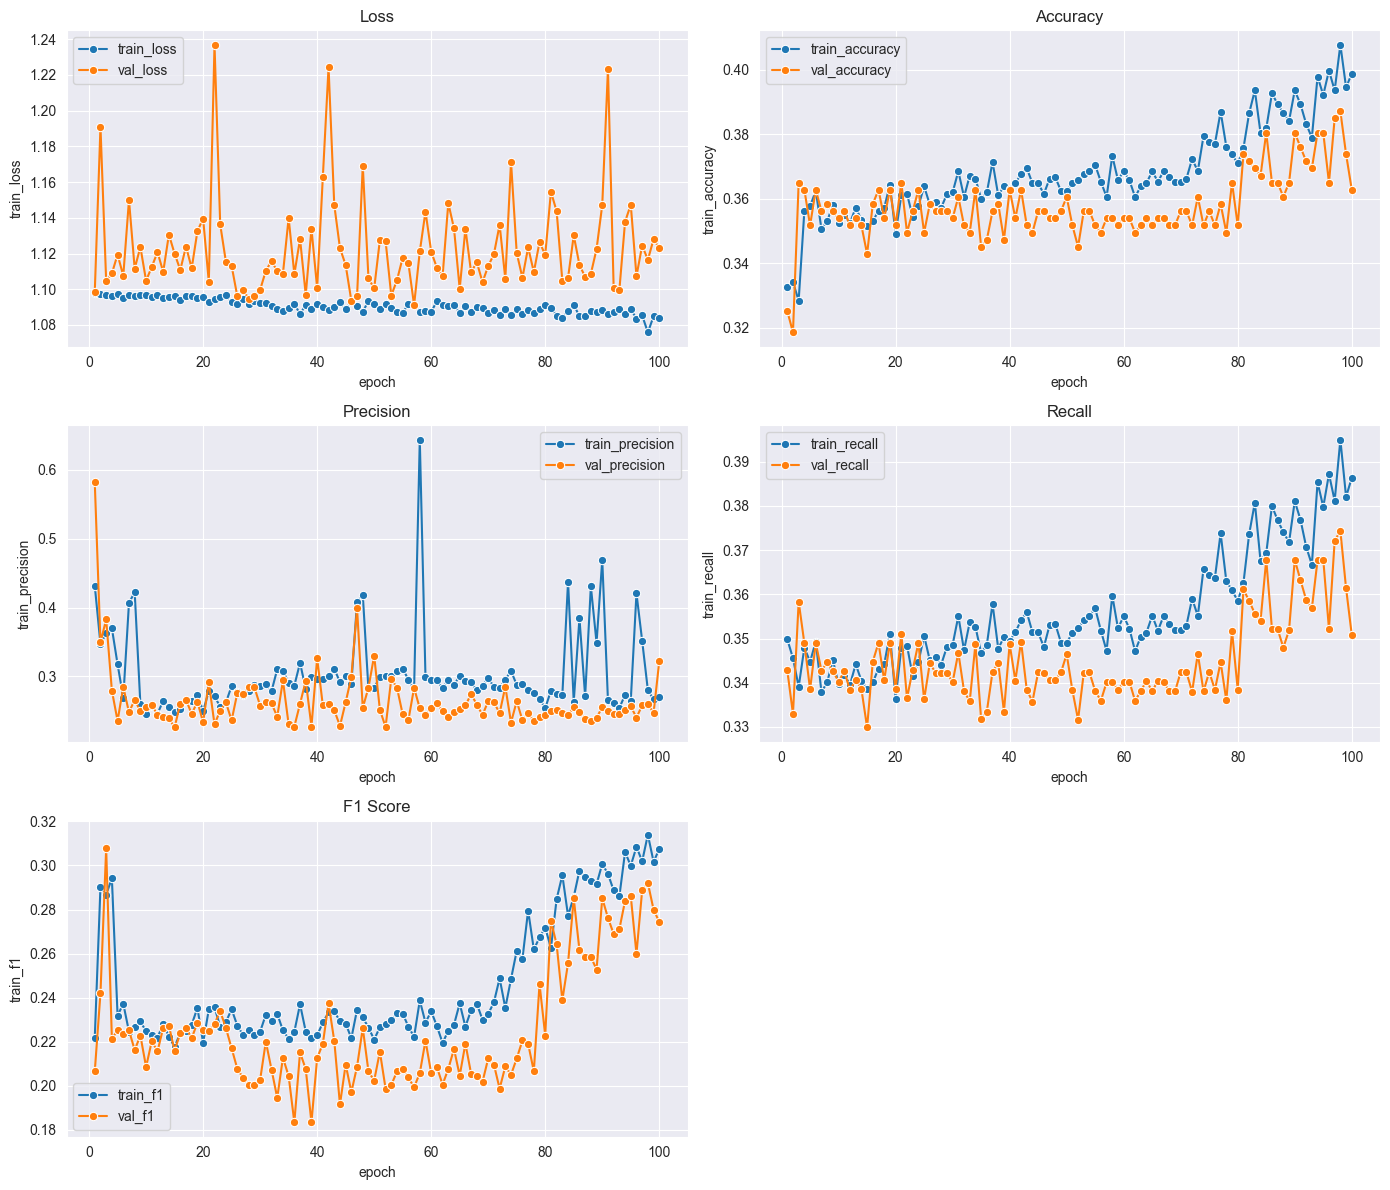

In [12]:
df = plot_training_metrics(history)
df.to_csv("../documentations/experiments/experiment5/tables/training_metrics.csv", index=False)

### Training/Validation Trend (100 epochs)
* Training loss steadily decreases (0.13 → ~0.02)
* Training accuracy saturates near 0.99–1.00 from early/mid epochs
* Training precision/recall/F1 remain ~0.99–1.00 after convergence
* Validation accuracy plateaus around ~0.82–0.85 with fluctuations
* Validation loss is unstable with repeated spikes (e.g., epochs 12, 31, 46, 79–80, 97)
* Persistent overfitting gap between train (~1.0) and validation (~0.83)
* Validation precision/recall/F1 remain moderate (~0.82–0.85) without clear upward trend
* Occasional sharp degradation in validation metrics despite strong training performance
* Confusion matrices mostly diagonal but inconsistent across epochs
* Best validation performance occurs intermittently, not progressively

Model behavior shows a clear pattern of rapid convergence on the training set followed by persistent overfitting. While training loss steadily decreases and training metrics reach near-perfect levels, validation performance stabilizes early and fluctuates within a narrow band without sustained improvement. The presence of repeated spikes in validation loss and occasional sharp drops in validation accuracy indicates instability in generalization, likely due to overfitting or sensitivity to specific validation samples. Confusion matrices remain broadly diagonal-dominant, but inconsistencies across epochs suggest that class-level errors are not fully resolved. Overall, the model learns the training distribution extremely well but fails to translate additional epochs into consistent validation gains.

## Use Tester Module to Test Model

Load Model with State Dict

In [13]:
import copy

test_scores = []

# Transforms of Data
test_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

# Dataset Loading From Image dir
test_dataset = datasets.ImageFolder(
    root="../datasets/fight-weaponized-other-dataset/test", 
    transform = test_transform 
    )

# DataLoader
test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=16,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
    )


tester = Tester(
    model,
    test_loader,
    3,
    torch.nn.CrossEntropyLoss(),
    "cuda"
)

test_scores = tester.test_all_checkpoints(
    "../models/experiment5"
)


Finished testing epoch 1
Finished testing epoch 2
Finished testing epoch 3
Finished testing epoch 10
Finished testing epoch 20
Finished testing epoch 30
Finished testing epoch 40
Finished testing epoch 50
Finished testing epoch 60
Finished testing epoch 70
Finished testing epoch 80
Finished testing epoch 81
Finished testing epoch 85
Finished testing epoch 90
Finished testing epoch 97
Finished testing epoch 98
Finished testing epoch 100


### Save Test Metrics

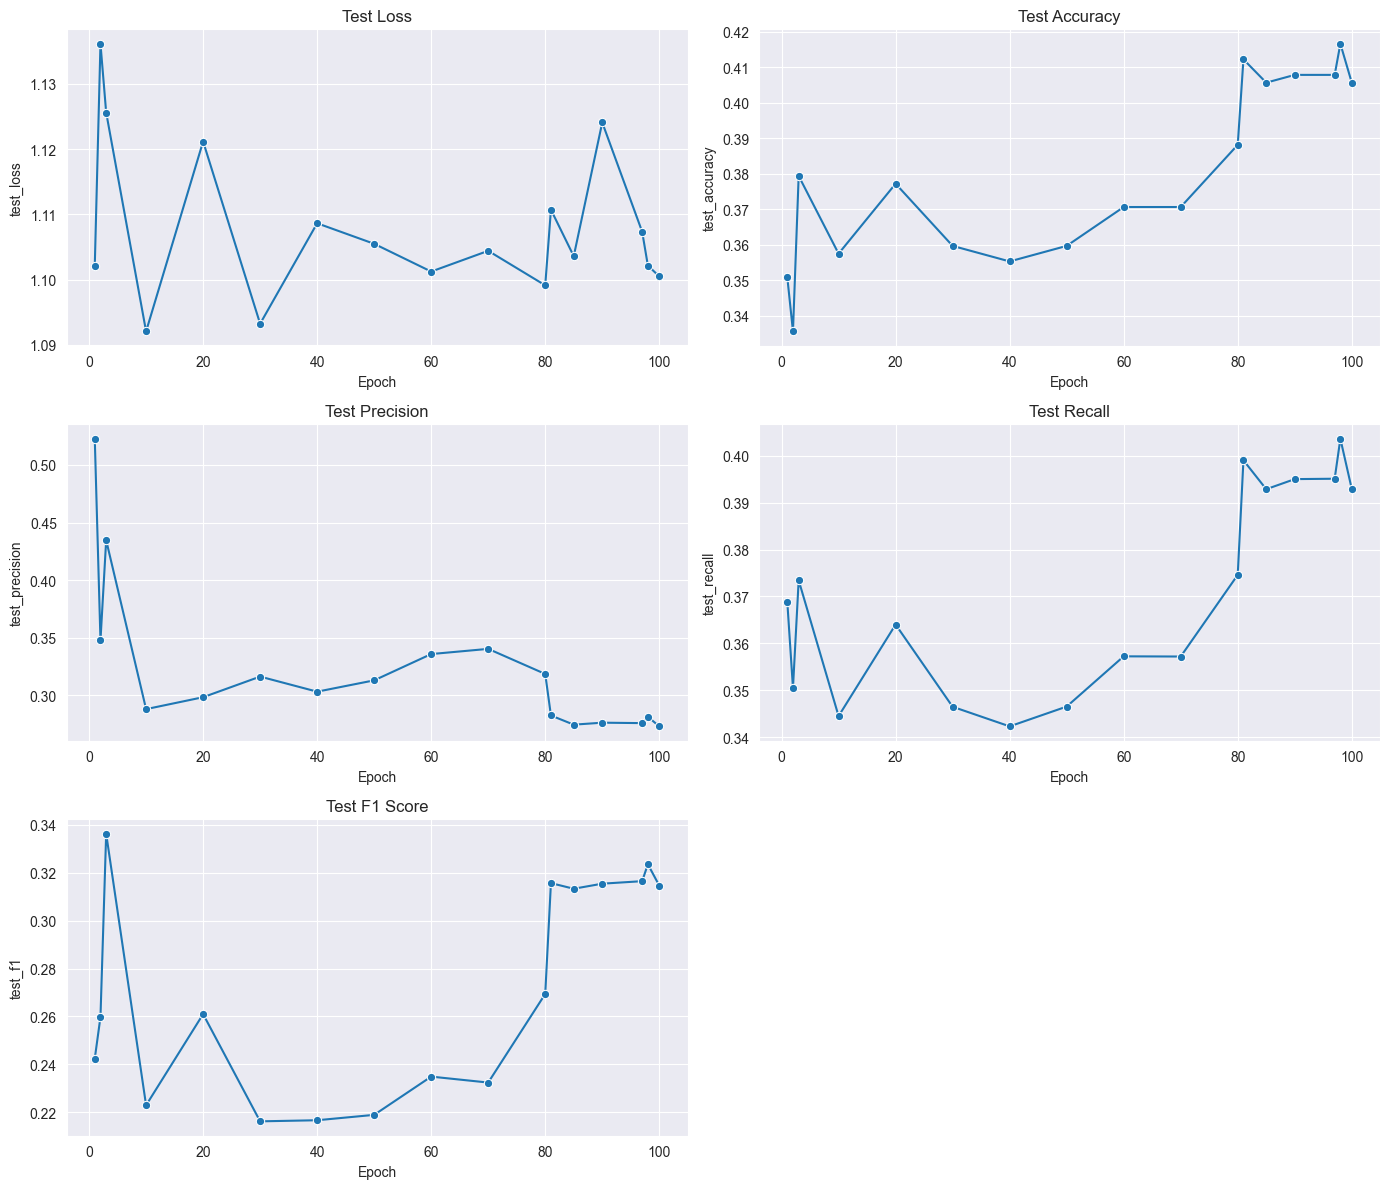

In [14]:
# Plot all 100 epochs
test_metrics_df = plot_testing_history(test_scores)
test_metrics_df.to_csv("../documentations/experiments/experiment5/tables/test_metrics.csv", index=False)

### Test Performance Trend (100 epochs)
* Test loss generally decreases early but fluctuates significantly throughout training
* Test loss shows repeated instability spikes (notably around epochs 8, 12, 31, 79–80, 97)
* Test accuracy stabilizes mostly in the ~0.83–0.87 range
* Occasional sharp drops in test accuracy (e.g., ~0.70–0.74 around epochs 12, 31, 80, 97)
* Test precision/recall/F1 remain closely aligned across epochs (balanced metrics)
* Best test performance appears around mid-to-late training (peaks near ~0.87 accuracy, epochs ~43–86 range)
* No strong monotonic improvement; performance oscillates around a stable band
* Periodic degradation aligns with spikes in test loss, indicating instability
* Model generalization is moderate and stable overall despite noise
* Final epochs recover good performance (~0.86 accuracy, strong precision/recall/F1)

The model achieves stable moderate generalization on test data (~0.84–0.87 accuracy) with balanced precision/recall/F1, but exhibits periodic instability with sharp loss spikes and occasional performance drops. Overall behavior indicates reasonable generalization with noise rather than consistent improvement.